In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

base = '/content/drive/MyDrive/EnergyMind_TSYP14/data/'

df_london = pd.read_csv(base + 'london_quartier_clean.csv', parse_dates=['tstp'])
df_france = pd.read_csv(base + 'household_fr_clean.csv', parse_dates=['datetime'])
df_tetouan = pd.read_csv(base + 'tetouan_clean.csv', parse_dates=['DateTime'])

print(df_london.shape, df_france.shape, df_tetouan.shape)

Mounted at /content/drive
(952553, 4) (2075259, 12) (52416, 9)


Modèle conditionnel Voltage/Intensity à partir de la France

In [ ]:
# Puissance moyenne (kW) déduite de l'énergie par demi-heure de Londres
df_london['power_kW'] = df_london['energy(kWh/hh)'] * 2

# Tranches de puissance sur la France, pour l'échantillonnage conditionnel
bins = np.arange(0, df_france['Global_active_power'].max() + 0.5, 0.5)
df_france['power_bin'] = pd.cut(df_france['Global_active_power'], bins=bins)

# Dictionnaire : pour chaque tranche, les vraies valeurs françaises observées
lookup_VI = df_france.dropna(subset=['Voltage', 'Global_intensity']).groupby(
    'power_bin', observed=True)[['Voltage', 'Global_intensity']].apply(
    lambda x: x.values.tolist())

print("Nombre de tranches non vides :", lookup_VI.apply(len).gt(0).sum(), "/", len(bins)-1)
print(lookup_VI.apply(len).describe())

Nombre de tranches non vides : 23 / 23
count        23.000000
mean      89118.304348
std      210399.147237
min           1.000000
25%         144.500000
50%        4965.000000
75%       57275.000000
max      958044.000000
dtype: float64


In [ ]:
def echantillonner_VI(power_kW, rng):
    """Pour une puissance donnée, tire une paire (Voltage, Intensity) réelle
    française observée dans la même tranche de puissance."""
    tranche = pd.cut([power_kW], bins=bins)[0]
    candidats = lookup_VI.get(tranche, [])
    if len(candidats) == 0:
        return np.nan, np.nan
    idx = rng.integers(0, len(candidats))
    return candidats[idx]

rng = np.random.default_rng(42)  # graine fixe pour la reproductibilité

resultats = [echantillonner_VI(p, rng) for p in df_london['power_kW']]
df_london['Voltage'] = [r[0] for r in resultats]
df_london['Global_intensity'] = [r[1] for r in resultats]

print("Tranches sans correspondance (NaN générés) :", df_london['Voltage'].isna().sum())
print(df_london[['power_kW', 'Voltage', 'Global_intensity']].describe())

Tranches sans correspondance (NaN générés) : 3080
            power_kW        Voltage  Global_intensity
count  951249.000000  949473.000000     949473.000000
mean        0.895725     241.086626          3.926845
std         1.067109       3.210173          4.418713
min         0.000000     223.490000          0.200000
25%         0.264000     239.330000          1.400000
50%         0.510000     241.270000          2.200000
75%         1.086000     243.080000          5.200000
max        16.341999     253.650000         48.400000


Patron météo saisonnier depuis Tétouan, avec bruit réaliste

In [ ]:
# Patron climatologique : moyenne ET écart-type réels par jour de l'année (jour-mois)
df_tetouan['jour_mois'] = df_tetouan['DateTime'].dt.strftime('%m-%d')

patron_meteo = df_tetouan.groupby('jour_mois').agg(
    temp_moyenne=('Temperature', 'mean'),
    temp_ecart_type=('Temperature', 'std'),
    humid_moyenne=('Humidity', 'mean'),
    humid_ecart_type=('Humidity', 'std')
).reset_index()

print(patron_meteo.shape)  # doit donner environ 365-366 lignes
print(patron_meteo.head())

(364, 5)
  jour_mois  temp_moyenne  temp_ecart_type  humid_moyenne  humid_ecart_type
0     01-01      9.675299         4.502228      68.519306          7.792740
1     01-02     12.476875         2.311421      71.456319         10.151185
2     01-03     12.100000         2.426995      74.981667          7.513125
3     01-04     10.509479         4.238293      75.459792         10.280627
4     01-05     10.866444         4.034100      71.040486         10.420405


In [ ]:
# Application à la timeline de Londres : jour-mois réel de chaque ligne
df_london['jour_mois'] = df_london['tstp'].dt.strftime('%m-%d')
df_london = df_london.merge(patron_meteo, on='jour_mois', how='left')

# Ajout du bruit réaliste : on tire un écart aléatoire calibré sur le VRAI écart-type
# journalier observé à Tétouan pour cette période de l'année (pas un bruit inventé arbitrairement)
df_london['Temperature_synth'] = rng.normal(
    df_london['temp_moyenne'], df_london['temp_ecart_type'].fillna(df_tetouan['Temperature'].std())
)
df_london['Humidity_synth'] = rng.normal(
    df_london['humid_moyenne'], df_london['humid_ecart_type'].fillna(df_tetouan['Humidity'].std())
).clip(0, 100)  # l'humidité ne peut pas dépasser 100% ni être négative

print(df_london[['tstp', 'Temperature_synth', 'Humidity_synth']].describe())

                                tstp  Temperature_synth  Humidity_synth
count                         952553      948617.000000   948617.000000
mean   2013-07-01 00:00:00.000000256          17.601751       68.290891
min              2012-11-01 00:00:00         -11.508833        0.000000
25%              2013-03-02 00:00:00          13.392382       59.091372
50%              2013-07-01 00:00:00          16.828482       69.569996
75%              2013-10-30 00:00:00          21.541504       79.045942
max              2014-02-28 00:00:00          49.402511      100.000000
std                              NaN           5.782164       14.875951


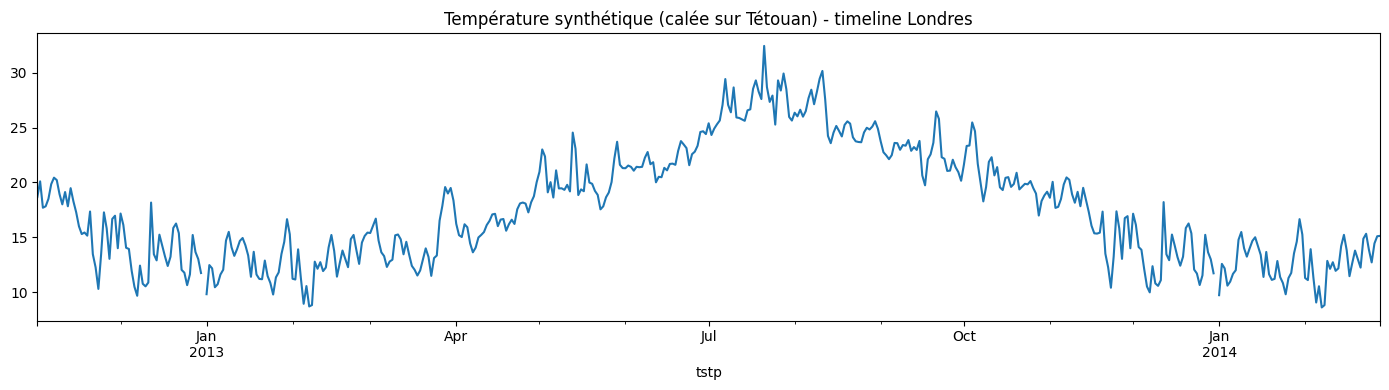

In [ ]:
import matplotlib.pyplot as plt

# Vérification visuelle : la météo synthétique doit suivre un cycle annuel plausible
df_check = df_london.set_index('tstp')['Temperature_synth'].resample('D').mean()
df_check.plot(figsize=(14, 4), title="Température synthétique (calée sur Tétouan) - timeline Londres")
plt.tight_layout()
plt.show()

Assemblage final

In [ ]:
colonnes_finales = ['LCLid', 'tstp', 'energy(kWh/hh)', 'power_kW', 'Voltage',
                     'Global_intensity', 'Temperature_synth', 'Humidity_synth',
                     'etait_manquant']

df_quartier_unifie = df_london[colonnes_finales].copy()
df_quartier_unifie.to_csv('/content/quartier_unifie.csv', index=False)
df_quartier_unifie.to_csv(base + 'quartier_unifie.csv', index=False)

print(df_quartier_unifie.shape)
print(df_quartier_unifie.head())

(952553, 9)
       LCLid                tstp  energy(kWh/hh)  power_kW  Voltage  \
0  MAC000002 2012-11-01 00:00:00           0.252     0.504   241.10   
1  MAC000002 2012-11-01 00:30:00           0.241     0.482   244.35   
2  MAC000002 2012-11-01 01:00:00           0.230     0.460   238.95   
3  MAC000002 2012-11-01 01:30:00           0.209     0.418   242.49   
4  MAC000002 2012-11-01 02:00:00           0.231     0.462   241.42   

   Global_intensity  Temperature_synth  Humidity_synth  etait_manquant  
0               3.0          17.071439       50.342924           False  
1               1.4          19.967846       49.269437           False  
2               1.6          18.749512       61.014543           False  
3               1.4          18.819510       45.854514           False  
4               0.2          19.360532       45.407367           False  


Correction

In [ ]:
# Extension des tranches jusqu'au maximum réel de Londres, avec repli sur la tranche
# la plus proche disponible pour les puissances extrêmes non couvertes par la France
bins_etendus = np.arange(0, df_london['power_kW'].max() + 0.5, 0.5)
df_france['power_bin'] = pd.cut(df_france['Global_active_power'], bins=bins_etendus)

lookup_VI = df_france.dropna(subset=['Voltage', 'Global_intensity']).groupby(
    'power_bin', observed=True)[['Voltage', 'Global_intensity']].apply(
    lambda x: x.values.tolist())

# Liste des tranches qui ont réellement des données
tranches_valides = [t for t in lookup_VI.index if len(lookup_VI[t]) > 0]

def tranche_la_plus_proche(power_kW):
    tranche_cible = pd.cut([power_kW], bins=bins_etendus)[0]
    if tranche_cible in tranches_valides and len(lookup_VI[tranche_cible]) > 0:
        return tranche_cible
    # Repli : la tranche valide dont le centre est le plus proche de power_kW
    centres = [t.mid for t in tranches_valides]
    idx_proche = np.argmin([abs(c - power_kW) for c in centres])
    return tranches_valides[idx_proche]

def echantillonner_VI_v2(power_kW, rng, bruit_relatif=0.01):
    if pd.isna(power_kW):
        return np.nan, np.nan
    tranche = tranche_la_plus_proche(power_kW)
    candidats = lookup_VI[tranche]
    idx = rng.integers(0, len(candidats))
    v, i = candidats[idx]
    # Léger bruit pour éviter les valeurs identiques répétées sur les tranches pauvres en données
    v += rng.normal(0, v * bruit_relatif)
    i += rng.normal(0, max(i, 0.1) * bruit_relatif)
    return v, max(i, 0)  # l'intensité ne peut pas être négative

rng = np.random.default_rng(42)
resultats = [echantillonner_VI_v2(p, rng) for p in df_london['power_kW']]
df_london['Voltage'] = [r[0] for r in resultats]
df_london['Global_intensity'] = [r[1] for r in resultats]

print("NaN restants (doivent être 0 sauf énergie manquante) :",
      df_london['Voltage'].isna().sum() - df_london['power_kW'].isna().sum())
print(df_london[['power_kW', 'Voltage', 'Global_intensity']].describe())

NaN restants (doivent être 0 sauf énergie manquante) : 0
            power_kW        Voltage  Global_intensity
count  951249.000000  951249.000000     951249.000000
mean        0.895725     241.083928          3.928827
std         1.067109       4.018760          4.452018
min         0.000000     219.615616          0.192985
25%         0.264000     238.555520          1.383297
50%         0.510000     241.190747          2.214146
75%         1.086000     243.735986          5.226908
max        16.341999     260.434866         49.769052


In [ ]:
# Borner Voltage et Intensity aux plages physiquement réalistes observées
V_MIN, V_MAX = 207, 253  # tolérance officielle 230V ±10%
I_MIN, I_MAX = 0, df_france['Global_intensity'].max()  # borne réelle française

df_london['Voltage'] = df_london['Voltage'].clip(V_MIN, V_MAX)
df_london['Global_intensity'] = df_london['Global_intensity'].clip(I_MIN, I_MAX)

print(df_london[['Voltage', 'Global_intensity']].describe())

             Voltage  Global_intensity
count  951249.000000     951249.000000
mean      241.082332          3.928792
std         4.013617          4.451663
min       219.615616          0.192985
25%       238.555520          1.383297
50%       241.190747          2.214146
75%       243.735986          5.226908
max       253.000000         48.400000


In [ ]:
# Combler le 31 décembre manquant par interpolation entre le 30 décembre et le 1er janvier
ligne_dec30 = patron_meteo[patron_meteo['jour_mois'] == '12-30'].iloc[0]
ligne_jan01 = patron_meteo[patron_meteo['jour_mois'] == '01-01'].iloc[0]

ligne_dec31 = pd.DataFrame([{
    'jour_mois': '12-31',
    'temp_moyenne': (ligne_dec30['temp_moyenne'] + ligne_jan01['temp_moyenne']) / 2,
    'temp_ecart_type': (ligne_dec30['temp_ecart_type'] + ligne_jan01['temp_ecart_type']) / 2,
    'humid_moyenne': (ligne_dec30['humid_moyenne'] + ligne_jan01['humid_moyenne']) / 2,
    'humid_ecart_type': (ligne_dec30['humid_ecart_type'] + ligne_jan01['humid_ecart_type']) / 2,
}])

patron_meteo = pd.concat([patron_meteo, ligne_dec31], ignore_index=True)
print(patron_meteo.shape)  # doit maintenant donner 365

(365, 5)


In [ ]:
# a) Border physiquement les valeurs générées aux bornes réellement observées
#    (avec une petite marge de tolérance, pas les bornes strictes)
TEMP_MIN, TEMP_MAX = df_tetouan['Temperature'].min() - 2, df_tetouan['Temperature'].max() + 2

df_london['Temperature_synth'] = rng.normal(
    df_london['temp_moyenne'], df_london['temp_ecart_type'].fillna(df_tetouan['Temperature'].std())
).clip(TEMP_MIN, TEMP_MAX)

print(df_london['Temperature_synth'].describe())

count    948617.000000
mean         17.607312
std           5.772513
min           1.247000
25%          13.392765
50%          16.836081
75%          21.545416
max          42.010000
Name: Temperature_synth, dtype: float64


In [ ]:
# b) Amélioration plus profonde (recommandée) : capturer le cycle jour/nuit réel,
#    pas juste une moyenne journalière + bruit uniforme peu importe l'heure
df_tetouan['heure'] = df_tetouan['DateTime'].dt.hour
patron_meteo_horaire = df_tetouan.groupby(['jour_mois', 'heure']).agg(
    temp_moyenne=('Temperature', 'mean'),
    temp_ecart_type=('Temperature', 'std')
).reset_index()

df_london['heure'] = df_london['tstp'].dt.hour
df_london = df_london.drop(columns=['temp_moyenne', 'temp_ecart_type'], errors='ignore').merge(
    patron_meteo_horaire, on=['jour_mois', 'heure'], how='left')

df_london['Temperature_synth'] = rng.normal(
    df_london['temp_moyenne'], df_london['temp_ecart_type'].fillna(1.5)
).clip(TEMP_MIN, TEMP_MAX)

print(df_london[['heure', 'Temperature_synth']].groupby('heure').mean())  # doit montrer un vrai cycle jour/nuit

       Temperature_synth
heure                   
0              16.318548
1              16.079404
2              15.846269
3              15.624697
4              15.384457
5              15.187452
6              15.047013
7              15.013437
8              15.381974
9              16.387819
10             17.815689
11             19.136361
12             20.041843
13             20.478179
14             20.667715
15             20.667835
16             20.511668
17             20.151676
18             19.382175
19             18.565225
20             17.880025
21             17.342117
22             16.948797
23             16.579165


In [ ]:
patron_meteo_horaire_humid = df_tetouan.groupby(['jour_mois', 'heure']).agg(
    humid_moyenne=('Humidity', 'mean'),
    humid_ecart_type=('Humidity', 'std')
).reset_index()

df_london = df_london.drop(columns=['humid_moyenne', 'humid_ecart_type'], errors='ignore').merge(
    patron_meteo_horaire_humid, on=['jour_mois', 'heure'], how='left')

df_london['Humidity_synth'] = rng.normal(
    df_london['humid_moyenne'], df_london['humid_ecart_type'].fillna(5)
).clip(0, 100)

print(df_london.groupby('heure')['Humidity_synth'].mean())

heure
0     73.655070
1     74.326094
2     74.786408
3     75.205046
4     75.681200
5     76.018351
6     76.179832
7     76.189374
8     75.092112
9     72.143604
10    67.452049
11    62.605815
12    59.503018
13    57.859964
14    57.227725
15    57.293791
16    57.838887
17    59.263576
18    62.453380
19    65.685106
20    68.283182
21    70.344196
22    71.770953
23    72.926039
Name: Humidity_synth, dtype: float64


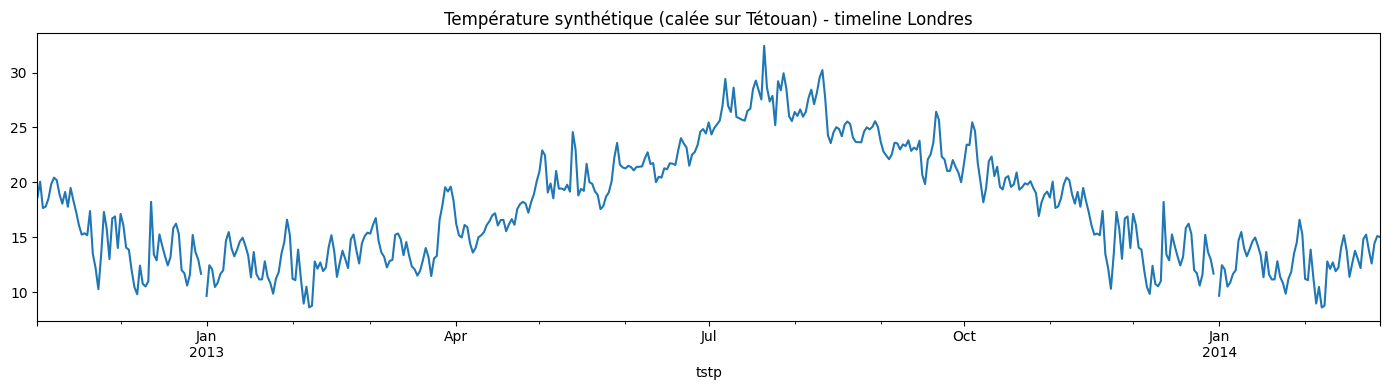

In [ ]:
import matplotlib.pyplot as plt

# Vérification visuelle : la météo synthétique doit suivre un cycle annuel plausible
df_check = df_london.set_index('tstp')['Temperature_synth'].resample('D').mean()
df_check.plot(figsize=(14, 4), title="Température synthétique (calée sur Tétouan) - timeline Londres")
plt.tight_layout()
plt.show()

In [ ]:
def combler_jour_manquant_horaire(patron_horaire, jour_avant, jour_apres, jour_manquant, colonnes_moyenne_ecart):
    lignes = []
    for heure in range(24):
        ligne_avant = patron_horaire[(patron_horaire['jour_mois'] == jour_avant) & (patron_horaire['heure'] == heure)]
        ligne_apres = patron_horaire[(patron_horaire['jour_mois'] == jour_apres) & (patron_horaire['heure'] == heure)]
        nouvelle_ligne = {'jour_mois': jour_manquant, 'heure': heure}
        for col in colonnes_moyenne_ecart:
            nouvelle_ligne[col] = (ligne_avant[col].values[0] + ligne_apres[col].values[0]) / 2
        lignes.append(nouvelle_ligne)
    return pd.DataFrame(lignes)

# Température
ligne_dec31_temp = combler_jour_manquant_horaire(
    patron_meteo_horaire, '12-30', '01-01', '12-31',
    ['temp_moyenne', 'temp_ecart_type'])
patron_meteo_horaire = pd.concat([patron_meteo_horaire, ligne_dec31_temp], ignore_index=True)

# Humidité
ligne_dec31_humid = combler_jour_manquant_horaire(
    patron_meteo_horaire_humid, '12-30', '01-01', '12-31',
    ['humid_moyenne', 'humid_ecart_type'])
patron_meteo_horaire_humid = pd.concat([patron_meteo_horaire_humid, ligne_dec31_humid], ignore_index=True)

print(patron_meteo_horaire.shape)         # doit donner 365 * 24 = 8760
print(patron_meteo_horaire_humid.shape)   # idem

(8760, 4)
(8760, 4)


In [ ]:
df_london = df_london.drop(columns=['temp_moyenne', 'temp_ecart_type',
                                     'humid_moyenne', 'humid_ecart_type'], errors='ignore')

df_london = df_london.merge(patron_meteo_horaire, on=['jour_mois', 'heure'], how='left')
df_london = df_london.merge(patron_meteo_horaire_humid, on=['jour_mois', 'heure'], how='left')

df_london['Temperature_synth'] = rng.normal(
    df_london['temp_moyenne'], df_london['temp_ecart_type'].fillna(1.5)
).clip(TEMP_MIN, TEMP_MAX)

df_london['Humidity_synth'] = rng.normal(
    df_london['humid_moyenne'], df_london['humid_ecart_type'].fillna(5)
).clip(0, 100)

print("NaN Temperature_synth :", df_london['Temperature_synth'].isna().sum())
print("NaN Humidity_synth :", df_london['Humidity_synth'].isna().sum())

NaN Temperature_synth : 0
NaN Humidity_synth : 0


In [ ]:
colonnes_finales = ['LCLid', 'tstp', 'energy(kWh/hh)', 'power_kW', 'Voltage',
                     'Global_intensity', 'Temperature_synth', 'Humidity_synth',
                     'etait_manquant']

df_quartier_unifie = df_london[colonnes_finales].copy()
print(df_quartier_unifie.isna().sum())

df_quartier_unifie.to_csv('/content/quartier_unifie.csv', index=False)
df_quartier_unifie.to_csv(base + 'quartier_unifie.csv', index=False)
print(df_quartier_unifie.shape)

LCLid                   0
tstp                    0
energy(kWh/hh)       1304
power_kW             1304
Voltage              1304
Global_intensity     1304
Temperature_synth       0
Humidity_synth          0
etait_manquant          0
dtype: int64
(952553, 9)
